<a href="https://colab.research.google.com/github/vugaer/ml-models/blob/main/15-9_well_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Download the dataset from kaggle

In [1]:
# If you want to Download the dataset, please uncomment following lines

import kagglehub
download_path = kagglehub.dataset_download("faresazzam/well-logs-dataset-for-machine-learning")
!mv {download_path}/* ./
!rm -rf sample_data  # Delete stuff comes with colab in every startup

Using Colab cache for faster access to the 'well-logs-dataset-for-machine-learning' dataset.
mv: cannot remove '/kaggle/input/well-logs-dataset-for-machine-learning/15_9_14_well.csv': Read-only file system
mv: cannot remove '/kaggle/input/well-logs-dataset-for-machine-learning/15_9-23.csv': Read-only file system
mv: cannot remove '/kaggle/input/well-logs-dataset-for-machine-learning/16_2-7.csv': Read-only file system
mv: cannot remove '/kaggle/input/well-logs-dataset-for-machine-learning/16_7-6.csv': Read-only file system
mv: cannot remove '/kaggle/input/well-logs-dataset-for-machine-learning/17_4-1.csv': Read-only file system
mv: cannot remove '/kaggle/input/well-logs-dataset-for-machine-learning/25_10_10_well.csv': Read-only file system
mv: cannot remove '/kaggle/input/well-logs-dataset-for-machine-learning/25_10-9.csv': Read-only file system
mv: cannot remove '/kaggle/input/well-logs-dataset-for-machine-learning/25_11_24_well.csv': Read-only file system
mv: cannot remove '/kaggle/in

In [2]:
# Let's check if our datasets are downloaded to our main
!ls -l

total 60140
-rw-r--r-- 1 1000 1000 4969120 Jan 27 13:37  15_9_14_well.csv
-rw-r--r-- 1 1000 1000 2990968 Jan 27 13:37  15_9-23.csv
-rw-r--r-- 1 1000 1000 3138877 Jan 27 13:37  16_2-7.csv
-rw-r--r-- 1 1000 1000 3074241 Jan 27 13:37  16_7-6.csv
-rw-r--r-- 1 1000 1000 3734562 Jan 27 13:37  17_4-1.csv
-rw-r--r-- 1 1000 1000 2546262 Jan 27 13:37  25_10_10_well.csv
-rw-r--r-- 1 1000 1000 2899898 Jan 27 13:37  25_10-9.csv
-rw-r--r-- 1 1000 1000 1129675 Jan 27 13:37  25_11_24_well.csv
-rw-r--r-- 1 1000 1000 2479354 Jan 27 13:37  25_5_3_well.csv
-rw-r--r-- 1 1000 1000 4263886 Jan 27 13:37  29_3_1_well.csv
-rw-r--r-- 1 1000 1000 2017776 Jan 27 13:37  31_2-10.csv
-rw-r--r-- 1 1000 1000 1991834 Jan 27 13:37 '31_2-21 S.csv'
-rw-r--r-- 1 1000 1000 2026646 Jan 27 13:37  31_6-5.csv
-rw-r--r-- 1 1000 1000 1908705 Jan 27 13:37  31_6-8.csv
-rw-r--r-- 1 1000 1000 6007089 Jan 27 13:37  34_10_16_R_well.csv
-rw-r--r-- 1 1000 1000 3154518 Jan 27 13:37 '34_3-2 S.csv'
-rw-r--r-- 1 1000 1000 4554327 Jan 27 13:37

# Data Overview `df1`

## Import Libraries

The used libraries are as follows:

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

## Preprocessing

We identify lithology codes.

In [4]:
df1 = pd.read_csv('15_9-23.csv')
df1.columns

Index(['WELL', 'DEPTH_MD', 'X_LOC', 'Y_LOC', 'Z_LOC', 'GROUP', 'FORMATION',
       'CALI', 'RSHA', 'RMED', 'RDEP', 'RHOB', 'GR', 'SGR', 'NPHI', 'PEF',
       'DTC', 'SP', 'BS', 'ROP', 'DTS', 'DCAL', 'DRHO', 'MUDWEIGHT', 'RMIC',
       'ROPA', 'RXO', 'FORCE_2020_LITHOFACIES_LITHOLOGY',
       'FORCE_2020_LITHOFACIES_CONFIDENCE'],
      dtype='object')

In [5]:
df1.head()

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,...,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE
0,15/9-23,1518.280,433906.75,6460000.5,-1493.241821,HORDALAND GP.,Skade Fm.,15.506232,NaN,NaN,...,146.526276,326.451263,-1.993768,0.109706,NaN,NaN,88.968864,NaN,65000,3.0
1,15/9-23,1518.432,433906.75,6460000.5,-1493.393799,HORDALAND GP.,Skade Fm.,18.524611,NaN,NaN,...,147.605148,322.926361,1.024611,-0.006418,NaN,NaN,92.287186,NaN,65000,3.0
2,15/9-23,1518.584,433906.75,6460000.5,-1493.545776,HORDALAND GP.,Skade Fm.,18.855669,NaN,NaN,...,140.783127,325.283142,1.355668,0.022769,NaN,NaN,95.605499,NaN,65000,3.0
3,15/9-23,1518.736,433906.75,6460000.5,-1493.697754,HORDALAND GP.,Skade Fm.,19.163353,NaN,NaN,...,125.159531,334.233185,1.663353,0.024972,NaN,NaN,98.923820,NaN,65000,3.0
4,15/9-23,1518.888,433906.75,6460000.5,-1493.849609,HORDALAND GP.,Skade Fm.,18.489744,NaN,0.849849,...,107.576691,330.952362,0.989743,0.024527,NaN,NaN,102.242142,NaN,65000,3.0


In the dataset source, their decoded version is mentioned.

| Code  | Lithology          |
|-------|--------------------|
| 30000 | Sandstone          |
| 65030 | Sandstone/Shale    |
| 65000 | Shale              |
| 80000 | Marl               |
| 74000 | Dolomite           |
| 70000 | Limestone          |
| 70032 | Chalk              |
| 88000 | Halite             |
| 86000 | Anhydrite          |
| 99000 | Tuff               |
| 90000 | Coal               |
| 93000 | Basement           |


In [6]:
lithology_mapping = {
    30000: "Sandstone",
    65030: "Sandstone/Shale",
    65000: "Shale",
    80000: "Marl",
    74000: "Dolomite",
    70000: "Limestone",
    70032: "Chalk",
    88000: "Halite",
    86000: "Anhydrite",
    99000: "Tuff",
    90000: "Coal",
    93000: "Basement",
}

df1['FORCE_2020_LITHOFACIES_LITHOLOGY'].unique()  # we have 8 lithologies mentioned

array([65000, 65030, 70000, 30000, 99000, 70032, 80000, 90000])

We have data imbalance there unfortunately.

In [7]:
df1_counts = (
    df1['FORCE_2020_LITHOFACIES_LITHOLOGY']
    .value_counts()
    .reset_index()
    .rename(columns={
        'FORCE_2020_LITHOFACIES_LITHOLOGY': 'Lithologies'
    })
)

df1_counts['Lithologies'] = df1_counts['Lithologies'].map(lithology_mapping)
df1_counts.set_index(['Lithologies'])

,count
Lithologies,
Shale,6731
Limestone,1630
Sandstone/Shale,1060
Marl,912
Sandstone,563
Tuff,74
Coal,64
Chalk,29


## Preprocessing

In [8]:
# Let's drop columns with the same value
df1 = df1.loc[:, df1.nunique() > 1]
# Bit Size should not have any effect on Lithology Determination
# Even so, we have depth column to show depth.
df1 = df1.drop(['BS'], axis=1)
df1.columns

Index(['DEPTH_MD', 'X_LOC', 'Y_LOC', 'Z_LOC', 'GROUP', 'FORMATION', 'CALI',
       'RMED', 'RDEP', 'RHOB', 'GR', 'NPHI', 'PEF', 'DTC', 'ROP', 'DTS',
       'DCAL', 'DRHO', 'ROPA', 'FORCE_2020_LITHOFACIES_LITHOLOGY',
       'FORCE_2020_LITHOFACIES_CONFIDENCE'],
      dtype='object')

In [9]:
df1.head()

,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RMED,RDEP,RHOB,...,NPHI,PEF,DTC,ROP,DTS,DCAL,DRHO,ROPA,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE
0,1518.280,433906.75,6460000.5,-1493.241821,HORDALAND GP.,Skade Fm.,15.506232,NaN,0.878615,NaN,...,0.439925,NaN,147.043427,146.526276,326.451263,-1.993768,0.109706,88.968864,65000,3.0
1,1518.432,433906.75,6460000.5,-1493.393799,HORDALAND GP.,Skade Fm.,18.524611,NaN,0.874237,NaN,...,0.504055,NaN,145.426468,147.605148,322.926361,1.024611,-0.006418,92.287186,65000,3.0
2,1518.584,433906.75,6460000.5,-1493.545776,HORDALAND GP.,Skade Fm.,18.855669,NaN,0.869858,NaN,...,0.512960,NaN,145.295105,140.783127,325.283142,1.355668,0.022769,95.605499,65000,3.0
3,1518.736,433906.75,6460000.5,-1493.697754,HORDALAND GP.,Skade Fm.,19.163353,NaN,0.865479,NaN,...,0.500070,NaN,143.657593,125.159531,334.233185,1.663353,0.024972,98.923820,65000,3.0
4,1518.888,433906.75,6460000.5,-1493.849609,HORDALAND GP.,Skade Fm.,18.489744,0.849849,0.863804,NaN,...,0.277670,NaN,142.838440,107.576691,330.952362,0.989743,0.024527,102.242142,65000,3.0


In [10]:
df1.isna().sum()

,0
DEPTH_MD,0
X_LOC,0
Y_LOC,0
Z_LOC,0
GROUP,0
FORMATION,0
CALI,0
RMED,54
RDEP,0
RHOB,54


In [11]:
df1

,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RMED,RDEP,RHOB,...,NPHI,PEF,DTC,ROP,DTS,DCAL,DRHO,ROPA,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE
0,1518.280,433906.75000,6460000.5,-1493.241821,HORDALAND GP.,Skade Fm.,15.506232,NaN,0.878615,NaN,...,0.439925,NaN,147.043427,146.526276,326.451263,-1.993768,0.109706,88.968864,65000,3.0
1,1518.432,433906.75000,6460000.5,-1493.393799,HORDALAND GP.,Skade Fm.,18.524611,NaN,0.874237,NaN,...,0.504055,NaN,145.426468,147.605148,322.926361,1.024611,-0.006418,92.287186,65000,3.0
2,1518.584,433906.75000,6460000.5,-1493.545776,HORDALAND GP.,Skade Fm.,18.855669,NaN,0.869858,NaN,...,0.512960,NaN,145.295105,140.783127,325.283142,1.355668,0.022769,95.605499,65000,3.0
3,1518.736,433906.75000,6460000.5,-1493.697754,HORDALAND GP.,Skade Fm.,19.163353,NaN,0.865479,NaN,...,0.500070,NaN,143.657593,125.159531,334.233185,1.663353,0.024972,98.923820,65000,3.0
4,1518.888,433906.75000,6460000.5,-1493.849609,HORDALAND GP.,Skade Fm.,18.489744,0.849849,0.863804,NaN,...,0.277670,NaN,142.838440,107.576691,330.952362,0.989743,0.024527,102.242142,65000,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11058,3212.016,433933.25000,6459977.0,-3186.522949,VESTLAND GP.,Skagerrak Fm.,8.622439,4.265228,2.660877,2.662135,...,NaN,6.211904,NaN,17.063992,NaN,0.122439,0.050846,21.664633,30000,1.0
11059,3212.168,433933.25000,6459977.0,-3186.674561,VESTLAND GP.,Skagerrak Fm.,8.654653,2.188407,1.651926,2.574645,...,NaN,5.445361,NaN,17.698082,NaN,0.154652,0.050241,23.712538,65030,1.0
11060,3212.320,433933.25000,6459977.0,-3186.826660,VESTLAND GP.,Skagerrak Fm.,8.596466,1.375046,1.310661,2.484784,...,NaN,5.160233,NaN,22.885672,NaN,0.096466,0.042768,25.760443,65030,1.0
11061,3212.472,433933.28125,6459977.0,-3186.978271,VESTLAND GP.,Skagerrak Fm.,8.673164,1.166480,1.262026,2.483438,...,NaN,5.000957,NaN,36.670067,NaN,0.173165,0.039578,27.808348,65000,1.0


In [12]:
categorical_cols = ['GROUP', 'FORMATION']

for col in categorical_cols:
    le = LabelEncoder()
    df1[col + '_ENCODED'] = le.fit_transform(df1[col])

df1 = df1.drop(columns=categorical_cols)
df1

,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,CALI,RMED,RDEP,RHOB,GR,NPHI,...,DTC,ROP,DTS,DCAL,DRHO,ROPA,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE,GROUP_ENCODED,FORMATION_ENCODED
0,1518.280,433906.75000,6460000.5,-1493.241821,15.506232,NaN,0.878615,NaN,103.451515,0.439925,...,147.043427,146.526276,326.451263,-1.993768,0.109706,88.968864,65000,3.0,1,12
1,1518.432,433906.75000,6460000.5,-1493.393799,18.524611,NaN,0.874237,NaN,94.124893,0.504055,...,145.426468,147.605148,322.926361,1.024611,-0.006418,92.287186,65000,3.0,1,12
2,1518.584,433906.75000,6460000.5,-1493.545776,18.855669,NaN,0.869858,NaN,93.586487,0.512960,...,145.295105,140.783127,325.283142,1.355668,0.022769,95.605499,65000,3.0,1,12
3,1518.736,433906.75000,6460000.5,-1493.697754,19.163353,NaN,0.865479,NaN,91.113373,0.500070,...,143.657593,125.159531,334.233185,1.663353,0.024972,98.923820,65000,3.0,1,12
4,1518.888,433906.75000,6460000.5,-1493.849609,18.489744,0.849849,0.863804,NaN,100.228333,0.277670,...,142.838440,107.576691,330.952362,0.989743,0.024527,102.242142,65000,3.0,1,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11058,3212.016,433933.25000,6459977.0,-3186.522949,8.622439,4.265228,2.660877,2.662135,59.231411,NaN,...,NaN,17.063992,NaN,0.122439,0.050846,21.664633,30000,1.0,4,13
11059,3212.168,433933.25000,6459977.0,-3186.674561,8.654653,2.188407,1.651926,2.574645,68.286255,NaN,...,NaN,17.698082,NaN,0.154652,0.050241,23.712538,65030,1.0,4,13
11060,3212.320,433933.25000,6459977.0,-3186.826660,8.596466,1.375046,1.310661,2.484784,85.151917,NaN,...,NaN,22.885672,NaN,0.096466,0.042768,25.760443,65030,1.0,4,13
11061,3212.472,433933.28125,6459977.0,-3186.978271,8.673164,1.166480,1.262026,2.483438,94.557449,NaN,...,NaN,36.670067,NaN,0.173165,0.039578,27.808348,65000,1.0,4,13


In [13]:
numerical_cols_with_nans = ['RMED', 'RHOB', 'NPHI', 'PEF', 'DTC', 'DTS', 'ROP', 'ROPA', 'FORCE_2020_LITHOFACIES_CONFIDENCE']
imputer = SimpleImputer(strategy='median')
df1[numerical_cols_with_nans] = imputer.fit_transform(df1[numerical_cols_with_nans])

X = df1.drop(columns=['FORCE_2020_LITHOFACIES_LITHOLOGY'], axis=1)
X

,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,CALI,RMED,RDEP,RHOB,GR,NPHI,PEF,DTC,ROP,DTS,DCAL,DRHO,ROPA,FORCE_2020_LITHOFACIES_CONFIDENCE,GROUP_ENCODED,FORMATION_ENCODED
0,1518.280,433906.75000,6460000.5,-1493.241821,15.506232,0.756025,0.878615,2.325151,103.451515,0.439925,5.886166,147.043427,146.526276,326.451263,-1.993768,0.109706,88.968864,3.0,1,12
1,1518.432,433906.75000,6460000.5,-1493.393799,18.524611,0.756025,0.874237,2.325151,94.124893,0.504055,5.886166,145.426468,147.605148,322.926361,1.024611,-0.006418,92.287186,3.0,1,12
2,1518.584,433906.75000,6460000.5,-1493.545776,18.855669,0.756025,0.869858,2.325151,93.586487,0.512960,5.886166,145.295105,140.783127,325.283142,1.355668,0.022769,95.605499,3.0,1,12
3,1518.736,433906.75000,6460000.5,-1493.697754,19.163353,0.756025,0.865479,2.325151,91.113373,0.500070,5.886166,143.657593,125.159531,334.233185,1.663353,0.024972,98.923820,3.0,1,12
4,1518.888,433906.75000,6460000.5,-1493.849609,18.489744,0.849849,0.863804,2.325151,100.228333,0.277670,5.886166,142.838440,107.576691,330.952362,0.989743,0.024527,102.242142,3.0,1,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11058,3212.016,433933.25000,6459977.0,-3186.522949,8.622439,4.265228,2.660877,2.662135,59.231411,0.337230,6.211904,133.210373,17.063992,292.924637,0.122439,0.050846,21.664633,1.0,4,13
11059,3212.168,433933.25000,6459977.0,-3186.674561,8.654653,2.188407,1.651926,2.574645,68.286255,0.337230,5.445361,133.210373,17.698082,292.924637,0.154652,0.050241,23.712538,1.0,4,13
11060,3212.320,433933.25000,6459977.0,-3186.826660,8.596466,1.375046,1.310661,2.484784,85.151917,0.337230,5.160233,133.210373,22.885672,292.924637,0.096466,0.042768,25.760443,1.0,4,13
11061,3212.472,433933.28125,6459977.0,-3186.978271,8.673164,1.166480,1.262026,2.483438,94.557449,0.337230,5.000957,133.210373,36.670067,292.924637,0.173165,0.039578,27.808348,1.0,4,13


For the next outputs, we have to remember that

```
0: Sandstone
1: Shale
2: Sandstone/Shale
3: Limestone
4: Chalk
5: Marl
6: Coal
7: Tuff
```

In [14]:
y = df1['FORCE_2020_LITHOFACIES_LITHOLOGY']
le = LabelEncoder()
y = le.fit_transform(y)

lithology_maps_new = [lithology_mapping[cls_code] for cls_code in le.classes_]  # Some lithologies' count are 0 in lithology_mapping.

for i, l in enumerate(lithology_maps_new):
    print(f'{i}: {l}')

0: Sandstone
1: Shale
2: Sandstone/Shale
3: Limestone
4: Chalk
5: Marl
6: Coal
7: Tuff


In [15]:
df1

,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,CALI,RMED,RDEP,RHOB,GR,NPHI,...,DTC,ROP,DTS,DCAL,DRHO,ROPA,FORCE_2020_LITHOFACIES_LITHOLOGY,FORCE_2020_LITHOFACIES_CONFIDENCE,GROUP_ENCODED,FORMATION_ENCODED
0,1518.280,433906.75000,6460000.5,-1493.241821,15.506232,0.756025,0.878615,2.325151,103.451515,0.439925,...,147.043427,146.526276,326.451263,-1.993768,0.109706,88.968864,65000,3.0,1,12
1,1518.432,433906.75000,6460000.5,-1493.393799,18.524611,0.756025,0.874237,2.325151,94.124893,0.504055,...,145.426468,147.605148,322.926361,1.024611,-0.006418,92.287186,65000,3.0,1,12
2,1518.584,433906.75000,6460000.5,-1493.545776,18.855669,0.756025,0.869858,2.325151,93.586487,0.512960,...,145.295105,140.783127,325.283142,1.355668,0.022769,95.605499,65000,3.0,1,12
3,1518.736,433906.75000,6460000.5,-1493.697754,19.163353,0.756025,0.865479,2.325151,91.113373,0.500070,...,143.657593,125.159531,334.233185,1.663353,0.024972,98.923820,65000,3.0,1,12
4,1518.888,433906.75000,6460000.5,-1493.849609,18.489744,0.849849,0.863804,2.325151,100.228333,0.277670,...,142.838440,107.576691,330.952362,0.989743,0.024527,102.242142,65000,3.0,1,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11058,3212.016,433933.25000,6459977.0,-3186.522949,8.622439,4.265228,2.660877,2.662135,59.231411,0.337230,...,133.210373,17.063992,292.924637,0.122439,0.050846,21.664633,30000,1.0,4,13
11059,3212.168,433933.25000,6459977.0,-3186.674561,8.654653,2.188407,1.651926,2.574645,68.286255,0.337230,...,133.210373,17.698082,292.924637,0.154652,0.050241,23.712538,65030,1.0,4,13
11060,3212.320,433933.25000,6459977.0,-3186.826660,8.596466,1.375046,1.310661,2.484784,85.151917,0.337230,...,133.210373,22.885672,292.924637,0.096466,0.042768,25.760443,65030,1.0,4,13
11061,3212.472,433933.28125,6459977.0,-3186.978271,8.673164,1.166480,1.262026,2.483438,94.557449,0.337230,...,133.210373,36.670067,292.924637,0.173165,0.039578,27.808348,65000,1.0,4,13


## Illustration

In [16]:
def plt_cm(y_true, y_pred, ticklabels=lithology_maps_new, model='NaN'):
    conf_matrix = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=ticklabels,
        yticklabels=ticklabels
    )
    plt.title(f'{model} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

## Determination of Models

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler ONLY on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame (optional, but good for consistency and feature names)
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

### Random Forest


In [18]:
rf_params = {
    'n_estimators': randint(100, 500),
    'max_features': ['sqrt', 'log2', None],
    'max_depth': randint(10, 100),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10)
}

rf_model = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_params,
    n_iter=15,
    cv=5,
    scoring='accuracy',
    random_state=42,
    verbose=3,
    n_jobs=-1
)

!echo "$(date) started."
random_search.fit(X_train, y_train)

!echo "$(date) finished."
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {random_search.best_score_:.4f}")

Wed Jan 28 01:22:20 AM UTC 2026 started.
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Wed Jan 28 01:43:36 AM UTC 2026 finished.
Best Parameters: {'max_depth': 56, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 149}
Best Cross-Validation Accuracy: 0.9671


In [19]:
best_rf_model = random_search.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)

print("RandomForest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=lithology_maps_new))

RandomForest Classification Report:
                 precision    recall  f1-score   support

      Sandstone       0.90      0.84      0.87       113
          Shale       0.99      0.99      0.99      1346
Sandstone/Shale       0.89      0.93      0.91       212
      Limestone       0.97      0.95      0.96       326
          Chalk       0.75      1.00      0.86         6
           Marl       0.92      0.95      0.93       182
           Coal       1.00      0.85      0.92        13
           Tuff       1.00      1.00      1.00        15

       accuracy                           0.97      2213
      macro avg       0.93      0.94      0.93      2213
   weighted avg       0.97      0.97      0.97      2213



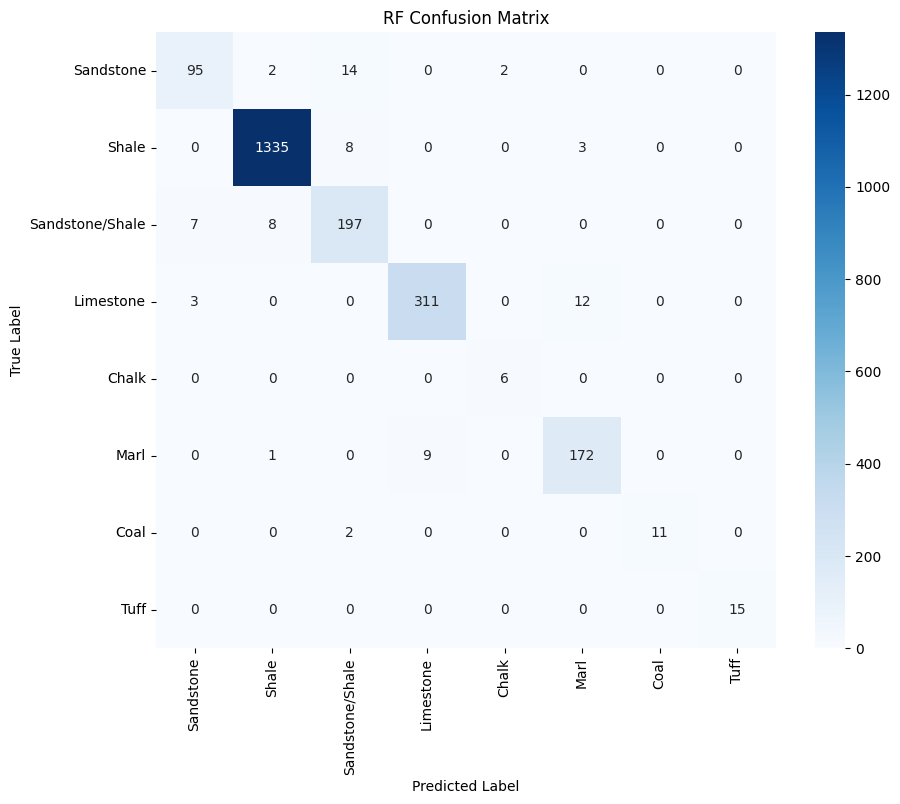

In [20]:
plt_cm(y_test, y_pred_rf, ticklabels=lithology_maps_new, model='RF')

### Support Vector

In [21]:
svc_params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svc_model = SVC(random_state=42)

random_search = RandomizedSearchCV(
    estimator=svc_model,
    param_distributions=svc_params,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=3
)

!echo "$(date) started."
random_search.fit(X_train, y_train)
!echo "$(date) finished."

print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {random_search.best_score_:.4f}")

Wed Jan 28 01:43:37 AM UTC 2026 started.
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Wed Jan 28 01:44:18 AM UTC 2026 finished.
Best Parameters: {'kernel': 'rbf', 'gamma': 'scale', 'C': 100}
Best Cross-Validation Accuracy: 0.9644


In [22]:
best_svc_model = random_search.best_estimator_
y_pred_svc = best_svc_model.predict(X_test)

print("SVC Classification Report:")
print(classification_report(y_test, y_pred_svc, target_names=lithology_maps_new))

SVC Classification Report:
                 precision    recall  f1-score   support

      Sandstone       0.93      0.89      0.91       113
          Shale       0.99      0.99      0.99      1346
Sandstone/Shale       0.90      0.93      0.91       212
      Limestone       0.96      0.95      0.96       326
          Chalk       1.00      0.83      0.91         6
           Marl       0.90      0.93      0.92       182
           Coal       1.00      0.77      0.87        13
           Tuff       0.88      1.00      0.94        15

       accuracy                           0.97      2213
      macro avg       0.95      0.91      0.93      2213
   weighted avg       0.97      0.97      0.97      2213



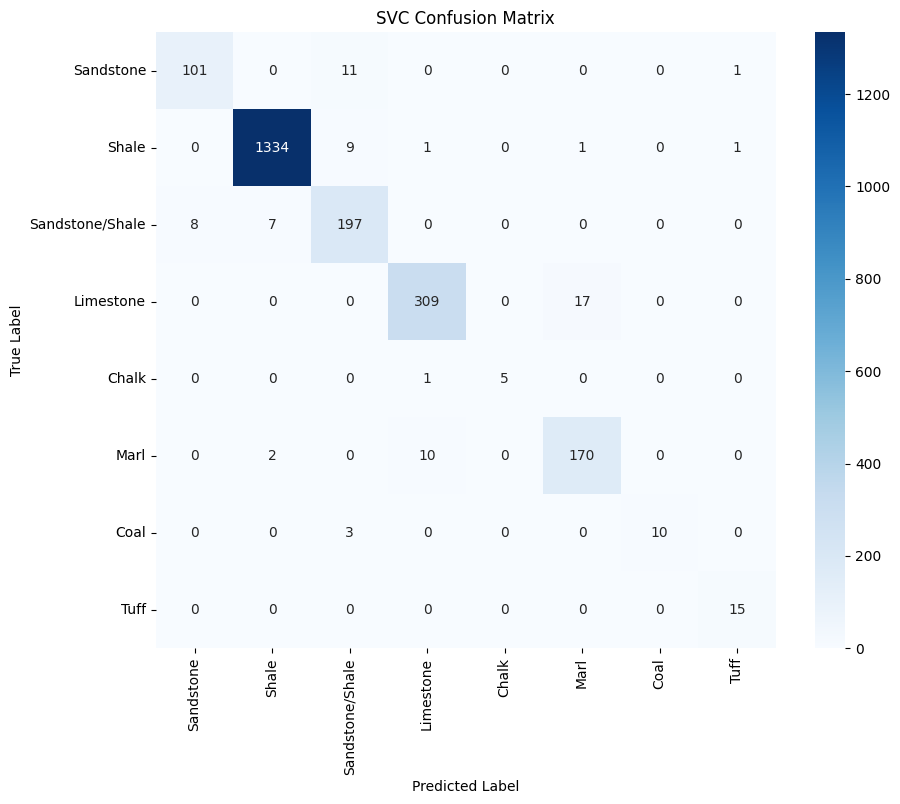

In [23]:
plt_cm(y_test, y_pred_svc, ticklabels=lithology_maps_new, model='SVC')